In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:\Project_3\data\DataCoSupplyChainDataset.csv", encoding= "latin1")

In [3]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
df.shape

(180519, 53)

In [5]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [6]:
df.dtypes

Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market          

In [7]:
df.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [8]:
df.duplicated().sum()

np.int64(0)

The dataset covers 180,519 orders placed between January 2015 and September 2017, across 53 fields. Data quality was strong from the start, only eight missing values in a single non-critical column, and no duplicate records - which meant the analysis could move quickly into feature engineering rather than extensive cleanup.

In [9]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

In [10]:
df.dtypes

Type                                     object
Days for shipping (real)                  int64
Days for shipment (scheduled)             int64
Benefit per order                       float64
Sales per customer                      float64
Delivery Status                          object
Late_delivery_risk                        int64
Category Id                               int64
Category Name                            object
Customer City                            object
Customer Country                         object
Customer Email                           object
Customer Fname                           object
Customer Id                               int64
Customer Lname                           object
Customer Password                        object
Customer Segment                         object
Customer State                           object
Customer Street                          object
Customer Zipcode                        float64
Department Id                           

In [11]:
df['Days to Ship'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days

In [12]:
df['On Time']= (df['Days to Ship'] <= df['Days for shipment (scheduled)']).astype(int)

In [13]:
df[['Days to Ship','Days for shipment (scheduled)','On Time']].head()

,Days to Ship,Days for shipment (scheduled),On Time
0,3,4,1
1,5,4,0
2,4,4,1
3,3,4,1
4,2,4,1


In [14]:
df['Month']= (df['order date (DateOrders)'].dt.to_period('M'))

Three derived fields anchor the entire analysis: shipping lead time, an on-time delivery flag, and a monthly time period. These were kept intentionally simple, since every subsequent metric - KPIs, trends, and forecasts - builds directly on them.

In [15]:
monthly_kpis = (df.groupby(['Month', 'Category Name']).agg(
    Total_Orders = ('Order Id', 'count'),
    Avg_Lead_Time = ('Days to Ship' , 'mean'),
    OTD_Pct = ('On Time', lambda x:x.mean()*100),
    Late_Count = ('On Time',  lambda x: (x == 0).sum())
).reset_index()
)

In [16]:
monthly_kpis.head()

,Month,Category Name,Total_Orders,Avg_Lead_Time,OTD_Pct,Late_Count
0,2015-01,Accessories,56,3.535714,42.857143,32
1,2015-01,Baseball & Softball,20,3.900000,25.000000,15
2,2015-01,Boxing & MMA,8,4.500000,12.500000,7
3,2015-01,Camping & Hiking,415,3.436145,48.674699,213
4,2015-01,Cardio Equipment,417,3.635492,42.446043,240


Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

As % of all orders:
Order Status
COMPLETE           32.96
PENDING_PAYMENT    22.07
PROCESSING         12.13
PENDING            11.20
CLOSED             10.87
ON_HOLD             5.43
SUSPECTED_FRAUD     2.25
CANCELED            2.05
PAYMENT_REVIEW      1.05
Name: count, dtype: float64


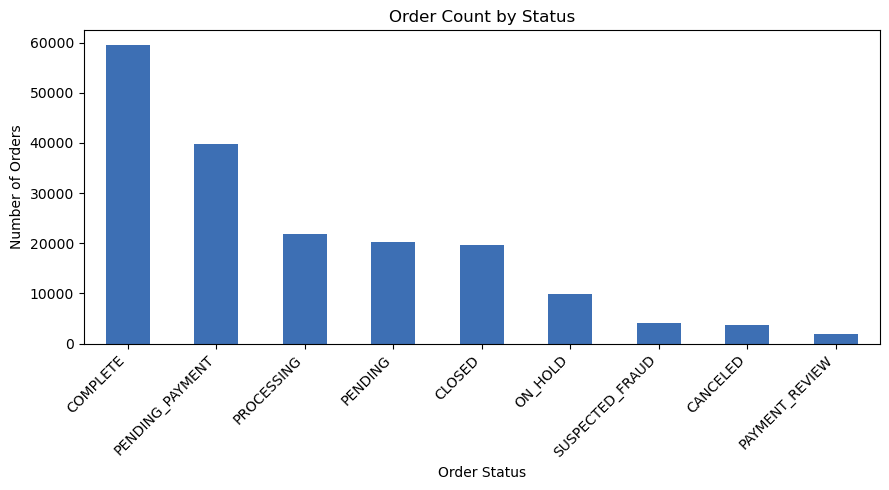

In [17]:
order_status_counts = df['Order Status'].value_counts()
print(order_status_counts)

order_status_pct = (order_status_counts / len(df) * 100).round(2)
print("\nAs % of all orders:")
print(order_status_pct)

order_status_counts.plot(kind='bar', figsize=(9,5), color='#3D6FB4')
plt.title("Order Count by Status")
plt.ylabel("Number of Orders")
plt.xlabel("Order Status")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('order_status_breakdown.png', dpi=120)
plt.show()

Overall Problem Order Rate: 10.78%


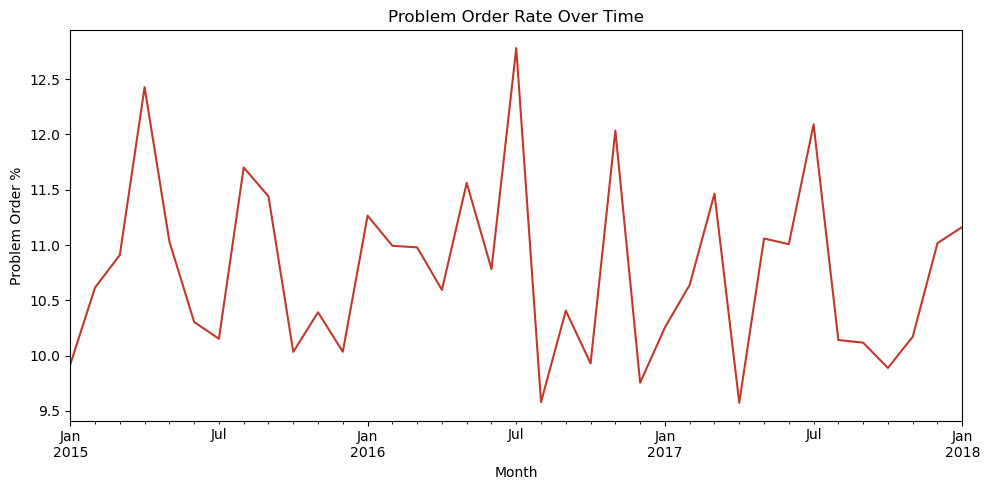

In [18]:
problem_statuses = ['CANCELED', 'SUSPECTED_FRAUD', 'ON_HOLD', 'PAYMENT_REVIEW']

df['Problem Order'] = df['Order Status'].isin(problem_statuses).astype(int)

overall_problem_rate = df['Problem Order'].mean() * 100
print(f"Overall Problem Order Rate: {overall_problem_rate:.2f}%")

monthly_problem_rate = (
    df.groupby('Month')['Problem Order']
      .mean()
      .mul(100)
)

monthly_problem_rate.plot(kind='line', figsize=(10,5), color='#C0392B')
plt.title("Problem Order Rate Over Time")
plt.ylabel("Problem Order %")
plt.xlabel("Month")
plt.tight_layout()
plt.savefig('problem_order_rate_trend.png', dpi=120)
plt.show()

monthly_problem_rate.to_csv('monthly_problem_order_rate.csv', header=['Problem_Order_Pct'])

                OTD_Pct  Problem_Order_Pct  Total_Orders
Market                                                  
Europe        44.981294          10.791610         50252
Pacific Asia  45.101794          10.816772         41260
USCA          45.358347          11.050816         25799
LATAM         45.602202          10.784200         51594
Africa        45.918719           9.901843         11614


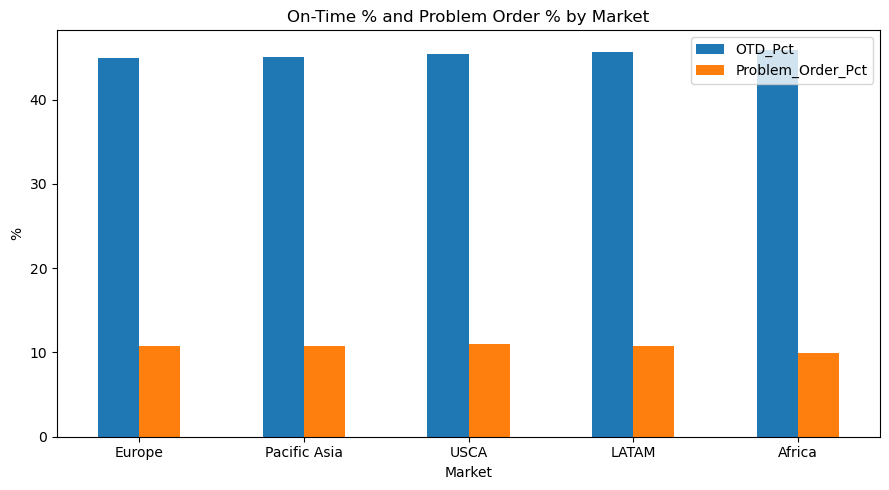

In [19]:
market_summary = df.groupby('Market').agg(
    OTD_Pct=('On Time', lambda x: x.mean()*100),
    Problem_Order_Pct=('Problem Order', lambda x: x.mean()*100),
    Total_Orders=('Order Id', 'count')
).sort_values('OTD_Pct')

print(market_summary)

market_summary[['OTD_Pct', 'Problem_Order_Pct']].plot(kind='bar', figsize=(9,5))
plt.title("On-Time % and Problem Order % by Market")
plt.ylabel("%")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('kpi_by_market.png', dpi=120)
plt.show()

                    OTD_Pct  Problem_Order_Pct  Total_Orders
Customer Segment                                            
Home Office       44.699932          10.727363         32226
Consumer          45.380946          10.961028         93504
Corporate         45.516436          10.485681         54789


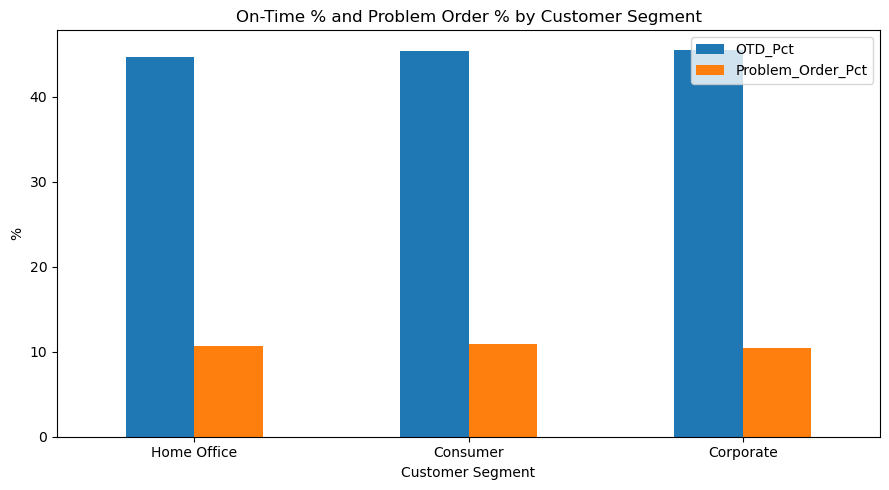

In [20]:
segment_summary = df.groupby('Customer Segment').agg(
    OTD_Pct=('On Time', lambda x: x.mean()*100),
    Problem_Order_Pct=('Problem Order', lambda x: x.mean()*100),
    Total_Orders=('Order Id', 'count')
).sort_values('OTD_Pct')

print(segment_summary)

segment_summary[['OTD_Pct', 'Problem_Order_Pct']].plot(kind='bar', figsize=(9,5))
plt.title("On-Time % and Problem Order % by Customer Segment")
plt.ylabel("%")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('kpi_by_segment.png', dpi=120)
plt.show()

                 Not At Risk %  Late Risk %
Order Status                               
PENDING                  42.10        57.90
PENDING_PAYMENT          42.45        57.55
COMPLETE                 42.51        57.49
PAYMENT_REVIEW           42.84        57.16
PROCESSING               42.91        57.09
CLOSED                   43.37        56.63
ON_HOLD                  44.41        55.59
CANCELED                100.00         0.00
SUSPECTED_FRAUD         100.00         0.00


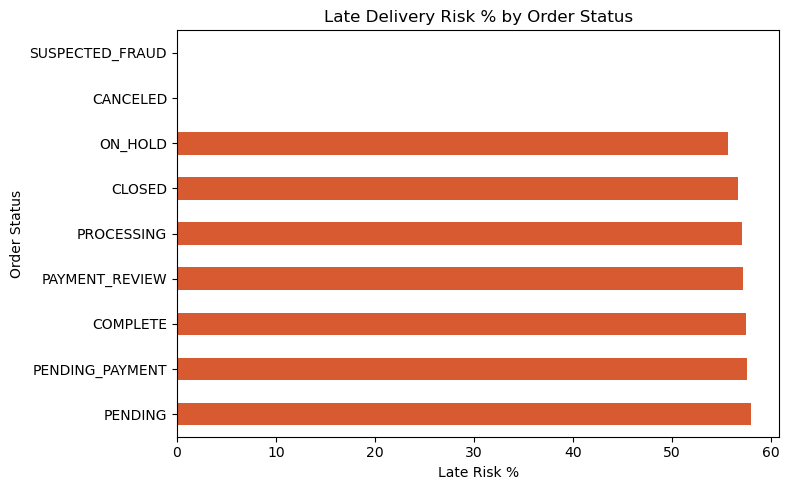

In [21]:
status_risk = pd.crosstab(df['Order Status'], df['Late_delivery_risk'], normalize='index') * 100
status_risk.columns = ['Not At Risk %', 'Late Risk %']
status_risk = status_risk.sort_values('Late Risk %', ascending=False)
print(status_risk.round(2))

status_risk['Late Risk %'].plot(kind='barh', figsize=(8,5), color='#D85A30')
plt.title("Late Delivery Risk % by Order Status")
plt.xlabel("Late Risk %")
plt.tight_layout()
plt.savefig('late_risk_by_status.png', dpi=120)
plt.show()

Digging into order status revealed that only a third of orders reach a clean "Complete" state. The rest sit across payment processing, holds, review, or cancellation. Roughly 1 in 10 orders (10.8%) requires manual intervention rather than flowing through automatically. What stood out most was how consistent this rate is: across every region, every customer segment, and every order status, the numbers barely move. That consistency is itself the finding - this isn't a regional or customer-specific issue, it's baked into the fulfillment process end to end. One nuance worth calling out: canceled and fraud-flagged orders technically show "0% late risk," but that's a reporting artifact - those orders never reached the shipping stage to begin with, not evidence they performed well.

In [22]:
monthly_kpis['Late_Delivery_Pct']= (monthly_kpis['Late_Count']/ monthly_kpis['Total_Orders'])*100

In [23]:
monthly_kpis[['Late_Delivery_Pct']].head()

,Late_Delivery_Pct
0,57.142857
1,75.000000
2,87.500000
3,51.325301
4,57.553957


In [24]:
monthly_kpis.to_csv("monthly_kpis_summary.csv",index=False)

A monthly summary of order volume, average lead time, on-time delivery rate, and late delivery rate by category forms the backbone of the project. It's the single source of truth that feeds the visualizations, the forecasting model, and the Excel dashboard.

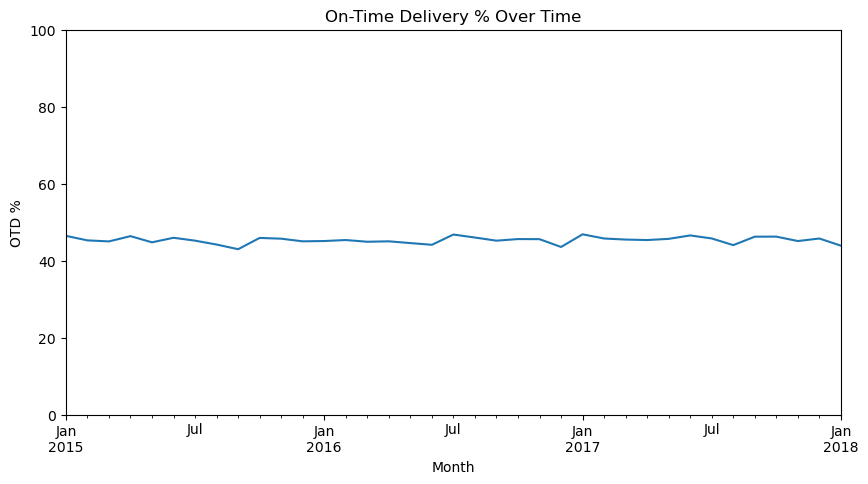

In [25]:
monthly_otd = (
    df.groupby('Month')['On Time'] .mean()* 100 )

monthly_otd.plot(
    kind='line',
    figsize=(10,5)
)

plt.title("On-Time Delivery % Over Time")
plt.ylabel("OTD %")
plt.ylim(0, 100)
plt.savefig("otd_over_time.png")
plt.show()

Company-wide, only 45.3% of orders ship on time. That figure holds fairly steady month over month, with no meaningful seasonal recovery or long-term improvement - this is the core problem the rest of the analysis is built around.

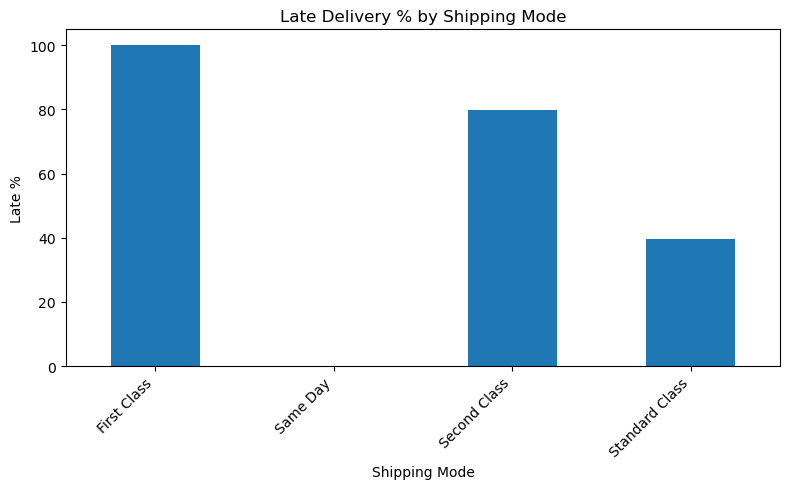

In [26]:
late_ship = (
    df.groupby('Shipping Mode')['On Time']
    .apply(lambda x: (1 - x.mean())*100)
)

late_ship.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Late Delivery % by Shipping Mode")
plt.ylabel("Late %")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("late_delivery_shipping_mode.png")
plt.show()

This is the most counterintuitive and most useful finding in the project. First Class shipments are late 100% of the time, Second Class 79.7%, Standard Class 39.8%, while Same Day delivery is late 0% of the time. In other words, customers paying for faster shipping are getting the least reliable service. That points to a clear, actionable recommendation: the scheduled delivery windows promised for First and Second Class are set unrealistically tight and should be reviewed against what operations can actually deliver.

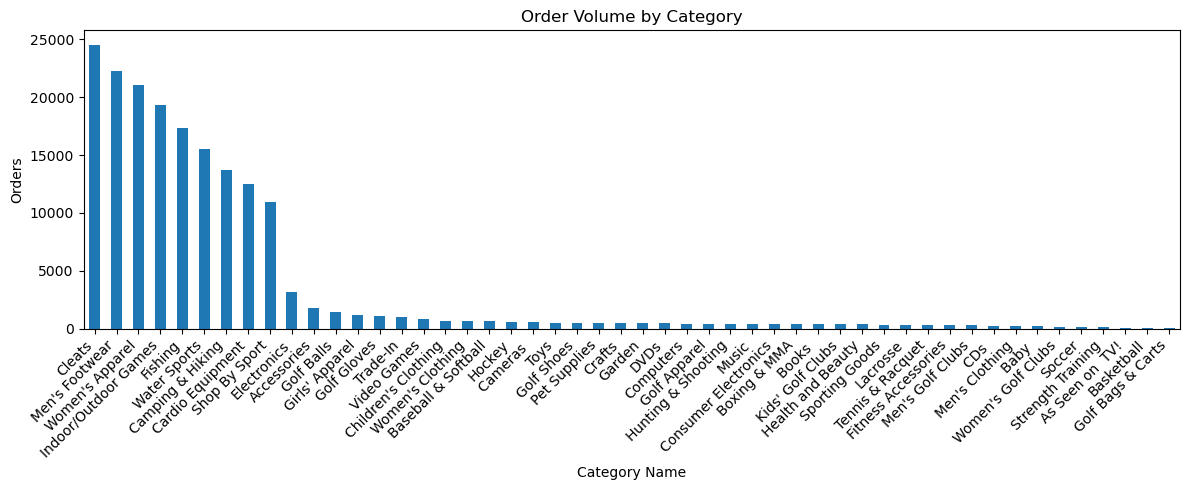

In [27]:
order_volume = (
    df.groupby('Category Name')
      ['Order Id']
      .count()
      .sort_values(ascending=False)
)

order_volume.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Order Volume by Category")
plt.ylabel("Orders")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("order_volume_category.png")
plt.show()

Cleats, Men's Footwear, and Women's Apparel are the three highest-volume categories by a clear margin, which is what made them the natural candidates for deeper demand forecasting.

In [28]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

In [29]:
categories = ['Cleats', "Men's Footwear", "Women's Apparel"]

In [30]:
monthly_demand = (
    df[df['Category Name'].isin(categories)]
    .groupby(['Month', 'Category Name'])['Order Item Quantity']
    .sum()
    .reset_index()
)
monthly_demand['Month'] = monthly_demand['Month'].dt.to_timestamp()
monthly_demand.head()

,Month,Category Name,Order Item Quantity
0,2015-01-01,Cleats,2390
1,2015-01-01,Men's Footwear,620
2,2015-01-01,Women's Apparel,1857
3,2015-02-01,Cleats,2005
4,2015-02-01,Men's Footwear,642


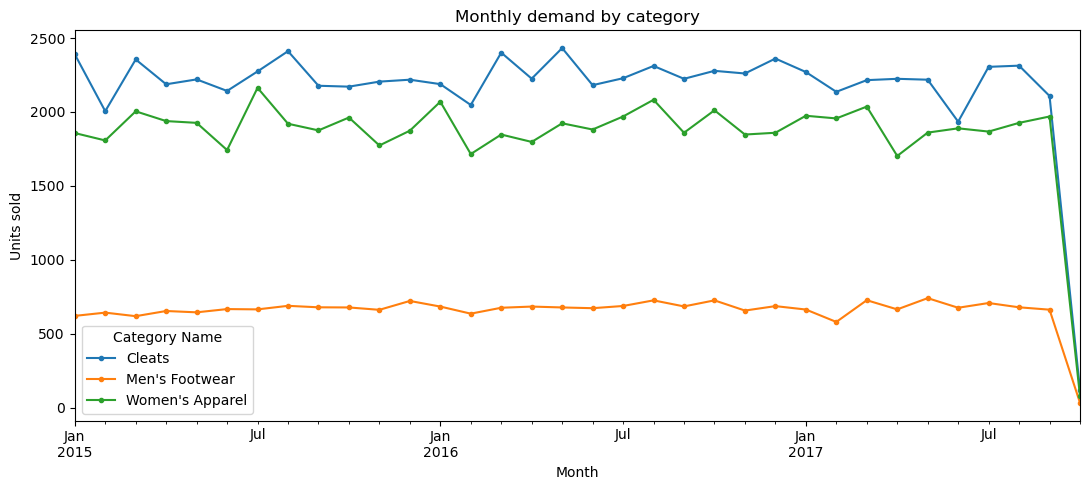

In [31]:
pivot = monthly_demand.pivot(index='Month', columns='Category Name', values='Order Item Quantity')

pivot.plot(figsize=(11,5), marker='o', markersize=3)
plt.title('Monthly demand by category')
plt.ylabel('Units sold')
plt.tight_layout()
plt.savefig('monthly_demand_trend.png', dpi=120)
plt.show()

In [32]:
cutoff = '2017-09'
series_dict = {}

for cat in categories:
    s = monthly_demand[monthly_demand['Category Name'] == cat].set_index('Month')['Order Item Quantity']
    s = s.asfreq('MS')
    s = s[:cutoff]
    series_dict[cat] = s
    
    result = adfuller(s.dropna())
    print(f"{cat}: ADF p-value = {result[1]:.4f}", "-> Stationary" if result[1] < 0.05 else "-> Not stationary, will difference")

Cleats: ADF p-value = 0.0000 -> Stationary
Men's Footwear: ADF p-value = 0.0127 -> Stationary
Women's Apparel: ADF p-value = 0.0000 -> Stationary


In [33]:
forecast_results = {}

for cat in categories:
    s = series_dict[cat]
    
    model = ARIMA(s, order=(1,1,1))
    fit = model.fit()
    
    forecast = fit.get_forecast(steps=6)
    pred = forecast.predicted_mean
    ci = forecast.conf_int(alpha=0.05)
    
    fitted_vals = fit.fittedvalues
    actual_vals = s[fitted_vals.index]
    mask = actual_vals != 0
    mape = (abs(actual_vals[mask] - fitted_vals[mask]) / actual_vals[mask]).mean() * 100
    
    forecast_results[cat] = {
        'forecast': pred,
        'lower_ci': ci.iloc[:, 0],
        'upper_ci': ci.iloc[:, 1],
        'mape': mape
    }
    
    print(f"{cat}: MAPE = {mape:.2f}%  |  AIC = {fit.aic:.1f}")

Cleats: MAPE = 6.79%  |  AIC = 399.0
Men's Footwear: MAPE = 6.69%  |  AIC = 322.6
Women's Apparel: MAPE = 7.46%  |  AIC = 396.3


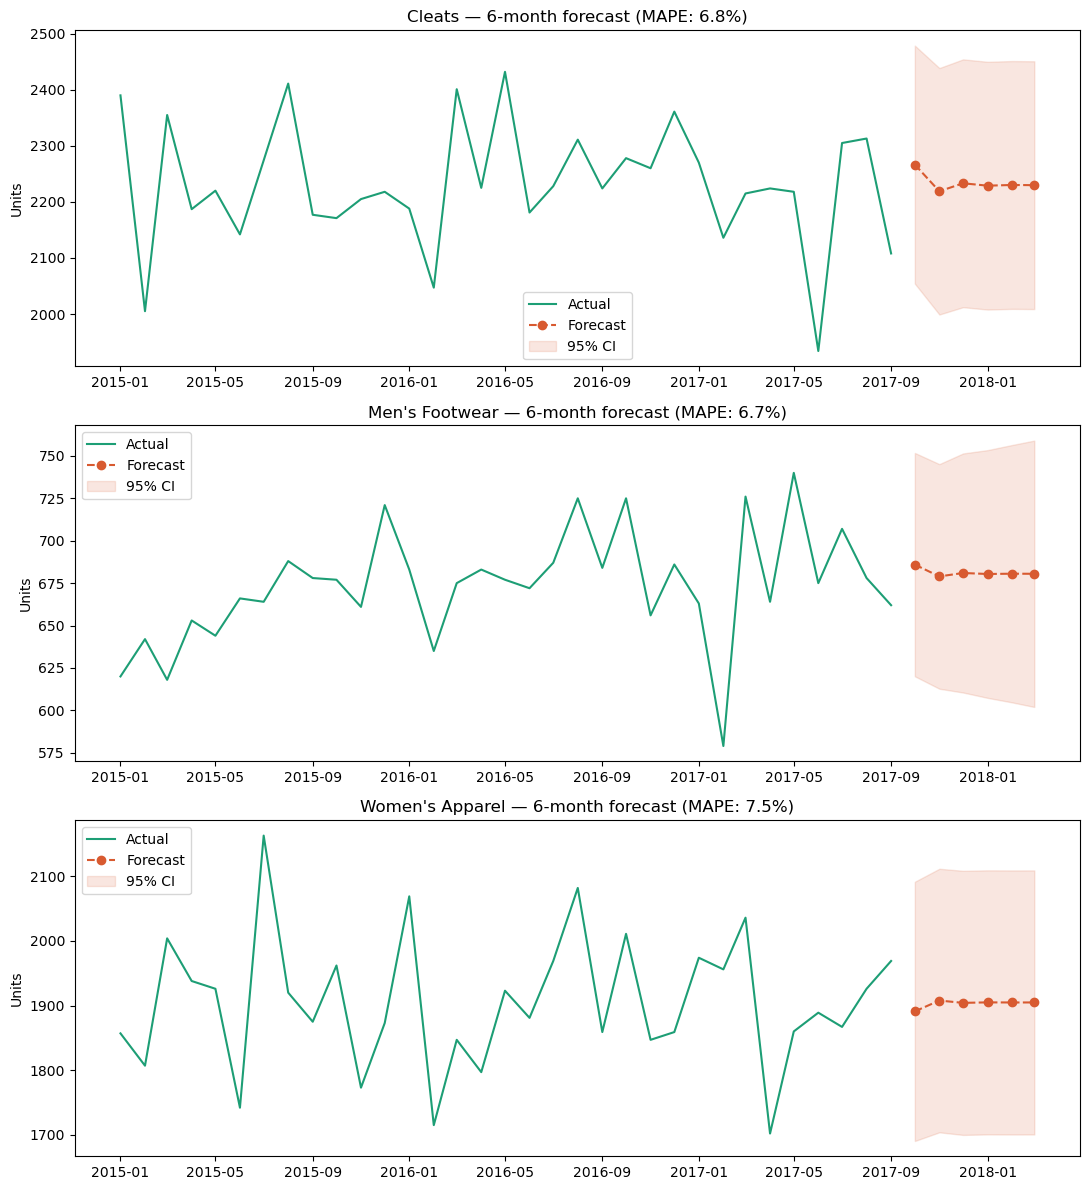

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(11, 12))

for i, cat in enumerate(categories):
    s = series_dict[cat]
    result = forecast_results[cat]
    
    axes[i].plot(s.index, s.values, label='Actual', color='#1D9E75')
    axes[i].plot(result['forecast'].index, result['forecast'].values, label='Forecast', color='#D85A30', linestyle='--', marker='o')
    axes[i].fill_between(result['forecast'].index, result['lower_ci'], result['upper_ci'], color='#D85A30', alpha=0.15, label='95% CI')
    
    axes[i].set_title(f"{cat} — 6-month forecast (MAPE: {result['mape']:.1f}%)")
    axes[i].set_ylabel('Units')
    axes[i].legend()

plt.tight_layout()
plt.savefig('forecast_with_ci.png', dpi=120)
plt.show()

In [35]:
export_rows = []

for cat in categories:
    s = series_dict[cat]
    result = forecast_results[cat]
    
    for date, val in s.items():
        export_rows.append({'Month': date, 'Category': cat, 'Type': 'Actual', 'Value': val, 'Lower_CI': None, 'Upper_CI': None})
    
    for date, val in result['forecast'].items():
        export_rows.append({
            'Month': date, 'Category': cat, 'Type': 'Forecast', 'Value': round(val, 0),
            'Lower_CI': round(result['lower_ci'][date], 0),
            'Upper_CI': round(result['upper_ci'][date], 0)
        })

forecast_output = pd.DataFrame(export_rows)
forecast_output.to_csv('forecast_output.csv', index=False)

mape_summary = pd.DataFrame([
    {'Category': cat, 'MAPE_pct': round(forecast_results[cat]['mape'], 2)}
    for cat in categories
])
mape_summary.to_csv('mape_summary.csv', index=False)

forecast_output.head()

,Month,Category,Type,Value,Lower_CI,Upper_CI
0,2015-01-01,Cleats,Actual,2390.0,NaN,NaN
1,2015-02-01,Cleats,Actual,2005.0,NaN,NaN
2,2015-03-01,Cleats,Actual,2355.0,NaN,NaN
3,2015-04-01,Cleats,Actual,2187.0,NaN,NaN
4,2015-05-01,Cleats,Actual,2220.0,NaN,NaN


A 6-month ARIMA forecast for these three categories achieved 6.7-7.5% MAPE - a strong result for a lightweight, interpretable model with no external inputs. It demonstrates that demand itself is highly predictable; the real volatility in this business isn't in what customers are buying, but in how reliably it gets shipped to them.

Demand is predictable, but fulfillment isn't. Only 45% of orders arrive on time and the pattern points less to where an order ships from and more to how it's shipped - premium shipping tiers are, paradoxically, the least reliable. The clearest opportunity for this business isn't in forecasting demand more precisely - it's already close to that ceiling but in closing the gap between what's promised at checkout and what operations can consistently deliver.